### Data Understanding 

In [1]:
# import libraires
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv file using read_csv 
df = pd.read_csv("netflix_titles.csv")

In [3]:
# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# (Row , Column )
df.shape

(8807, 12)

In [5]:
# incpect about the data ( columns , null values , data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# inspect about the numaric columns (statistical summary)
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# display last 5 rows 
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [8]:
# calculate the overall type values ( movies , TV shows)
type_counts = df["type"].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [9]:
df.groupby("country")["title"].count().sort_values(ascending=False).head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: title, dtype: int64

In [10]:
df.groupby("type")["release_year"].mean()

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64

<Axes: xlabel='type'>

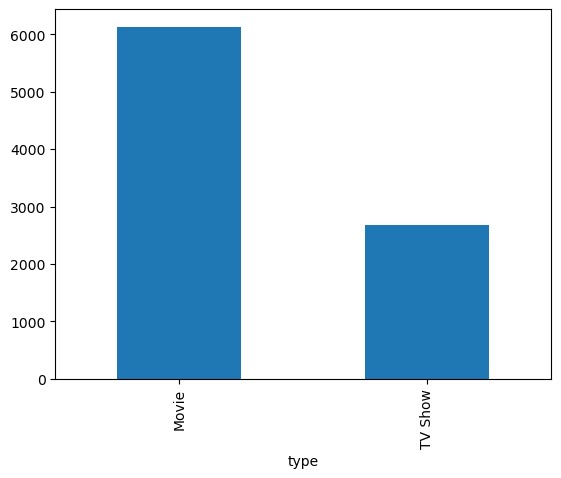

In [11]:
type_counts.plot(kind="bar")

### Data Cleaning 

In [12]:
# Creating a copy 
clean_df = df.copy()

In [13]:
# drop description column
clean_df.drop("description", axis = 1 , inplace = True )
clean_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [14]:
# check missing values 
clean_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

In [15]:
# Drop missing values
clean_df.dropna(inplace = True)
# if you want to fill missing values you can simply use fillna()

In [16]:
# standrize the type column ( lower case )
clean_df["type"] = clean_df["type"].str.lower()

In [17]:
# check 
clean_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s9,tv show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
9,s10,movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas"
12,s13,movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies"
24,s25,movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies"


In [18]:
# check if there is any duplicates rows
clean_df.duplicated().sum()
# clean_df.drop_duplicates(inplace = True)

np.int64(0)

### Data Processing 

In [19]:
# split country column
clean_df["country"] = clean_df["country"].str.split(",") 
clean_df = clean_df.explode("country")
clean_df["country"] = clean_df["country"].str.strip() 


In [20]:
clean_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Burkina Faso,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United Kingdom,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Germany,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [21]:
# handle date_added colum inconsitinces
clean_df["date_added"] = pd.to_datetime(clean_df["date_added"], errors = "coerce")

In [22]:
clean_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Burkina Faso,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United Kingdom,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Germany,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
7,s8,movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ethiopia,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s9,tv show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
9,s10,movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...",Germany,2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies"
12,s13,movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...",Czech Republic,2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies"


In [23]:
# Display specific coulmns using loc function
clean_df.loc[:,["title","type","country","rating"]].head(10)

,title,type,country,rating
7,Sankofa,movie,United States,TV-MA
7,Sankofa,movie,Ghana,TV-MA
7,Sankofa,movie,Burkina Faso,TV-MA
7,Sankofa,movie,United Kingdom,TV-MA
7,Sankofa,movie,Germany,TV-MA
7,Sankofa,movie,Ethiopia,TV-MA
8,The Great British Baking Show,tv show,United Kingdom,TV-14
9,The Starling,movie,United States,PG-13
12,Je Suis Karl,movie,Germany,TV-MA
12,Je Suis Karl,movie,Czech Republic,TV-MA


In [24]:
#  حددت من الجدول الافلام بس يعني نفس الجدول اعرض لي عمود التايب لما يكون عندي فلم و حددت الاعمده ف نستخدم لوك للعررض وللفلتره
# filter based on movies
clean_df.loc[clean_df["type"] == "movie" ,["title" ,"country" , "rating"]].head(10)

,title,country,rating
7,Sankofa,United States,TV-MA
7,Sankofa,Ghana,TV-MA
7,Sankofa,Burkina Faso,TV-MA
7,Sankofa,United Kingdom,TV-MA
7,Sankofa,Germany,TV-MA
7,Sankofa,Ethiopia,TV-MA
9,The Starling,United States,PG-13
12,Je Suis Karl,Germany,TV-MA
12,Je Suis Karl,Czech Republic,TV-MA
24,Jeans,India,TV-14


In [25]:
clean_df["release_group"] = np.where(
    clean_df["release_year"] >= 2018 , 
    "Recent", "Old" 
)

In [26]:
clean_df[["title","release_year","release_group"]].sample(10)

,title,release_year,release_group
3670,Cities of Last Things,2018,Recent
2579,Go! Go! Cory Carson: The Chrissy,2020,Recent
6210,Backtrack,2015,Old
8068,Spider-Man: Into the Spider-Verse,2018,Recent
2060,Always Be My Maybe,2016,Old
604,The Life of David Gale,2003,Old
8195,The Art of the Steal,2013,Old
3511,Avengement,2019,Recent
8338,The Haunting of Molly Hartley,2008,Old
314,Heavy,1995,Old


In [27]:
def classify_content(year): 
    if year >= 2018:
        return "Recent"
    else: 
        return "Old"
clean_df["release_group_apply"] = clean_df["release_year"].apply(classify_content)

In [28]:
clean_df[["release_year","release_group","release_group_apply"]].sample(10)

,release_year,release_group,release_group_apply
6243,2017,Old,Old
5872,2016,Old,Old
7633,2016,Old,Old
6557,2017,Old,Old
576,2019,Recent,Recent
7121,2001,Old,Old
5977,2005,Old,Old
3875,2019,Recent,Recent
7564,2004,Old,Old
5710,2012,Old,Old


## Matplotlib

<function matplotlib.pyplot.show(close=None, block=None)>

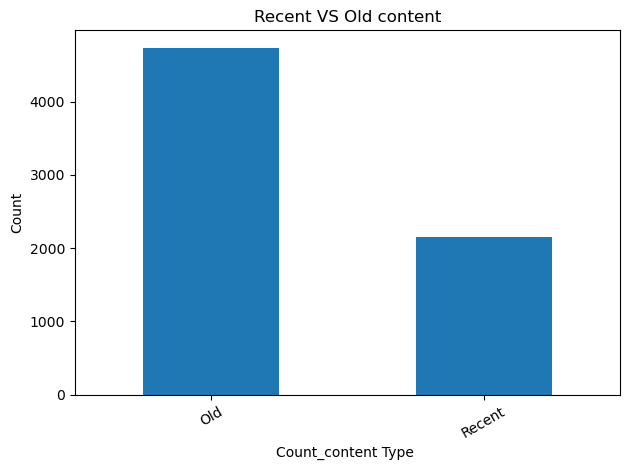

In [29]:
clean_df["release_group"].value_counts().plot(kind="bar")
plt.title("Recent VS Old content")
plt.xticks(rotation = 30)
plt.xlabel("Count_content Type ")
plt.ylabel("Count")
plt.tight_layout()
plt.show



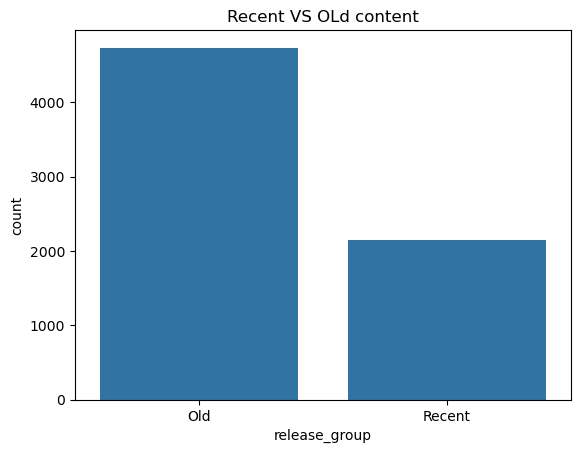

In [30]:
sns.countplot(data = clean_df , x = "release_group")
plt.title("Recent VS OLd content")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

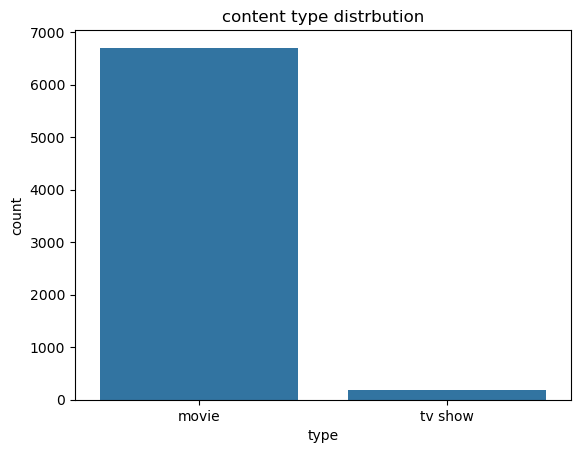

In [31]:
sns.countplot(data = clean_df , x="type")
plt.title("content type distrbution")
plt.show

In [33]:
top_countries = clean_df["country"].value_counts().head(10)
top_countries

country
United States     2485
India              940
United Kingdom     485
Canada             295
France             293
Germany            167
Spain              161
Japan              124
China              109
Mexico             101
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

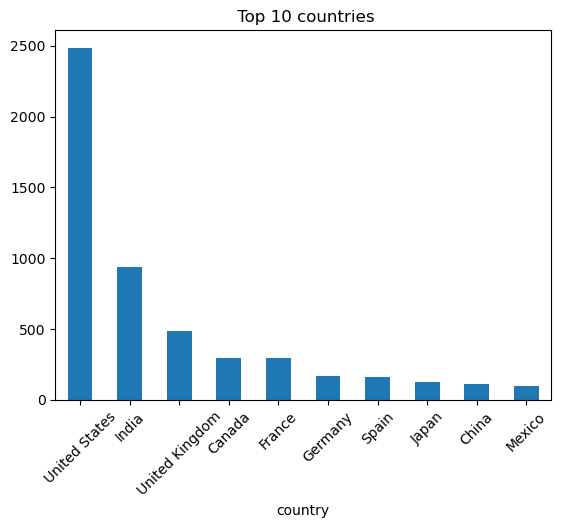

In [35]:
top_countries.plot(kind="bar")
plt.title(" Top 10 countries")
plt.xticks(rotation = 45)
plt.show

In [41]:
year_counts = clean_df["release_year"].value_counts().sort_index()

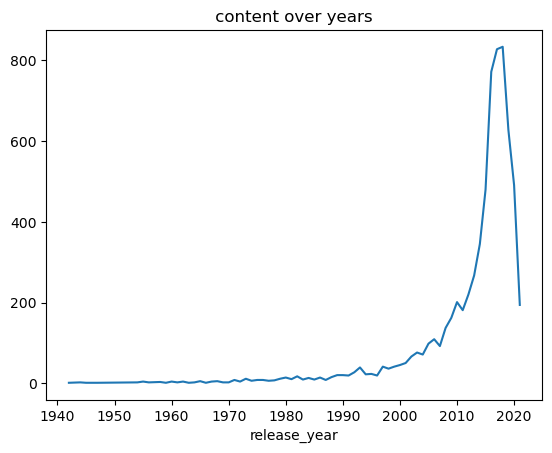

In [42]:
year_counts.plot(kind = "line")
plt.title(" content over years ")
plt.show()

In [43]:
top_rating = clean_df["rating"].value_counts().head(10)
top_rating


rating
TV-MA    2197
TV-14    1371
R        1214
PG-13     738
TV-PG     507
PG        417
TV-Y7     101
TV-Y       96
TV-G       93
NR         75
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

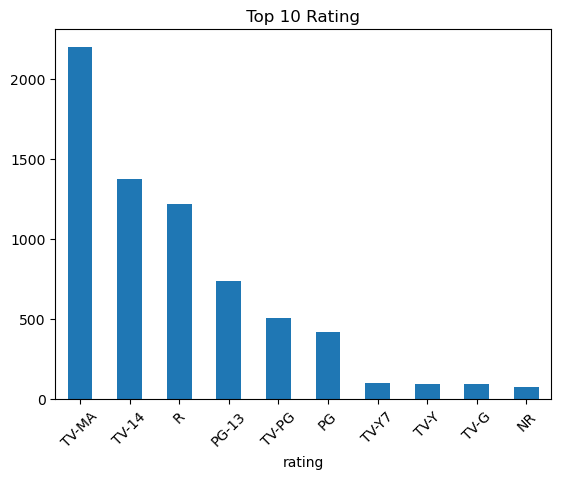

In [47]:
top_rating.plot(kind="bar")
plt.title(" Top 10 Rating ")
plt.xticks(rotation = 45)
plt.show